In [1]:
import pandas as pd
import numpy as np 
import random as rd
import matplotlib.pyplot as plt

First, we prepare data

In [2]:
df=pd.read_csv('nba_dataset.csv')
display(df.head())
print(f'Total rows : {df.shape[0]},\nTotal columns : {df.shape[1]}')
df_final=df.sort_values('match_date')

df['team_points_stats'] = df['team_points']
colonnes_meta = [
    'game_id', 
    'match_date', 
    'team_id', 
    'team_name',         
    'team_points',
    'is_home'     
]


colonnes_stats = [
    'team_points_stats',
    'ORTG',            
    'DRTG',            
    'possessions',     
    'FG_PCT',          
    '3FG_PCT',         
    'FTA',             
    'turnovers',       
    'OREB',            
    'opponent_points', 
    ]

df=df[colonnes_meta+colonnes_stats]

rolling_windows=[3,5,10]
df_grouped=df.groupby('team_name')
for feature in colonnes_stats: 
    for rolling_window in rolling_windows: 
        col_name = f"{feature}_last_{rolling_window}"
        try : 
            df[col_name] = df_grouped[feature].transform(
                lambda x: x.rolling(window=rolling_window).mean().shift(1)
            )
        except :
            print(col_name)
            pass

,Unnamed: 0,_id,tournament_id,season_id,game_id,match_date,team_id,team_name,team_fouls,team_points,...,shot_distance_count,shot_distance_sum,three_attempts,three_makes,three_points,total_points,uncontested_shot_attempts,uncontested_shot_makes,accurate_pass,turnovers
0,10696,2-615296,3,26,615296,2020-12-23 03:00:00,2,Golden State Warriors,24,99,...,99,418.940536,33,10,30,99,1,1,34,7
1,10697,3223-615296,3,26,615296,2020-12-23 03:00:00,3223,Brooklyn Nets,22,125,...,92,403.071409,35,15,45,125,2,2,27,14
2,10698,13-615303,3,26,615303,2020-12-23 06:00:00,13,Los Angeles Clippers,29,116,...,93,424.618979,40,14,42,116,5,5,25,12
3,10699,3171-615303,3,26,615303,2020-12-23 06:00:00,3171,Los Angeles Lakers,20,109,...,81,357.852316,29,9,27,109,4,4,28,9
4,10700,1-617993,3,26,617993,2020-12-24 03:00:00,1,Cleveland Cavaliers,22,121,...,87,356.026533,30,14,42,121,4,4,35,11


Total rows : 14746,
Total columns : 125


C:\Users\leand\AppData\Local\Temp\ipykernel_3404\60840726.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['team_points_stats'] = df['team_points']


Then, we have to add opponent team stat on each row.

In [3]:
rolling_features = [col for col in df.columns if '_last_' in col]+['is_home']
opponent_features = ['game_id', 'team_id','team_points'] + rolling_features

df_away = df[opponent_features].copy()
df_home = df[opponent_features].copy()

renaming_dict = {col: f"opp_{col}" for col in df_away.columns if col != 'game_id'} #renaming opponent features 
df_away = df_away.rename(columns=renaming_dict)

df_merged = pd.merge(df_home, df_away, on='game_id') #first merge


df_final = df_merged[df_merged['team_id'] != df_merged['opp_team_id']].reset_index(drop=True) #dropping rows merged on same team_id
df_final_without_na = df_final.dropna().reset_index(drop=True)

In [4]:
statistics_names = [col for col in df_final.columns if '_last_' in col] + ['is_home']


y=df_final_without_na['team_points'].values
x=np.array(df_final_without_na[statistics_names])

print(f"Shape of X : {x.shape}") 
print(f"Shape of Y : {y.shape}")

Shape of X : (14426, 61)
Shape of Y : (14426,)


Then, we build training and test sets. It is important to keep time order between training and testing to avoid data leakage. 

In [5]:
ratio=0.8
index_max=int(ratio*x.shape[0])

x_train=x[:index_max,:]
colonne_ones_train = np.ones((x_train.shape[0], 1))

x_test=x[index_max:,]
colonne_ones_test= np.ones((x_test.shape[0], 1))

y_train=y[:index_max,]
y_test=y[index_max:,]


We will need to standardize data (with train set data only to avoid data leakage)

In [6]:
def standardize(x_train,x):
    mean=np.mean(x_train,axis=0)
    sigma=np.std(x_train,axis=0)
    x_standardized=(x-mean)/sigma
    return x_standardized

In [7]:
x_train_standardize=standardize(x_train,x_train)
x_test_standardize=standardize(x_train,x_test)


#making sure x_train is standardized

assert np.allclose(np.mean(x_train_standardize,axis=0),np.zeros(x_train.shape[1])) , "training set must be centred"
assert np.allclose(np.std(x_train_standardize,axis=0),np.ones(x_train.shape[1])) ,"training set must be standardized"


colonne_ones_test= np.ones((x_test.shape[0], 1)) #for offset 
colonne_ones_train = np.ones((x_train.shape[0], 1))
x_train_augmente = np.hstack((colonne_ones_train, x_train_standardize)) 
x_test_augmente = np.hstack((colonne_ones_test,x_test_standardize))



Here we define gradient descent to minimize the loss

In [8]:
def grad_lasso(beta):
    return np.sign(beta)


In [9]:
def minimize_ls_lasso(X, y, lambd, n_iters = 15000, step_size=1e-7, c_huber=1e-5):
    """
    This function estimates the regression parameters using the gradient-descent algorithm to find the optimal
    solution.
    Args:
    X (np.array): The augmented data matrix with shape (N, p + 1).
    y (np.array): The response column with shape (N, 1).
    lambd (float): The multiplier of the relaxed L1 term.
    n_iters (int): Number of gradient descent iterations.
    step_size (float): The step size in the updating step.
    """

    # check X and y have the same length
    assert X.shape[0] == y.shape[0], "Input X and y have different lengths."

    N, p = X.shape
    # Precomputed products to avoid redundant computations.
    XX = X.T @ X
    Xy = X.T @ y
    # Initialize beta params with zeros
    beta = np.zeros(p)

    for _ in range(n_iters):

      
        grad_l= grad_lasso(beta)
    
        # Intercept term is not involved in the regularisation.
        grad_l[0]=0
    

        # Compute the gradient of the regularised loss.
        grad = 2*(XX @ beta - Xy) + lambd * grad_l 
       

        # Update beta
        beta = beta - step_size * grad
        

    return beta

To find the best lambda, we proceed a T-fold cross validation, but we don't sample folds at random as we need to keep time order to avoid data leakage in training. Here, each fold is included in the following, starting from the beginning of time, and the validation set is the following set in time. 



As a loss function to minimize, we use the ranked probability score (RPS), which compare two discrete cumulative distribution function. It is well known in sports industry. 

In [10]:
def ranked_probability_score(predictions, y_true, support):
    """
    Compute average RPS 
    """
    n_samples = predictions.shape[0]
    n_classes = len(support)
    
    cdf_preds = np.cumsum(predictions, axis=1)
    cdf_true = np.zeros((n_samples, n_classes))
    
    for i in range(n_samples):
        true_index = np.where(support == y_true[i])[0][0]
        cdf_true[i, true_index:] = 1.0
        
    rps_per_sample = np.sum((cdf_preds - cdf_true)**2, axis=1)
    
    return np.mean(rps_per_sample)

However, we need to discretise normal distributions as it is the underlying model in linear regressions. To do so, we use the module scipy which provide the cdf of normal. 

In [11]:
from scipy.stats import norm

def discretize_normal_cdf(mu_vector, sigma, support_max=200): #we suppose points go from 0 to 200

    mu_col = np.asarray(mu_vector).reshape(-1, 1)
    
    support_row = np.arange(support_max + 1).reshape(1, -1)
    
    upper_bounds = support_row + 0.5
    lower_bounds = support_row - 0.5
    
    prob_matrix = norm.cdf(upper_bounds, loc=mu_col, scale=sigma) - norm.cdf(lower_bounds, loc=mu_col, scale=sigma)
    
    prob_matrix = prob_matrix / np.sum(prob_matrix, axis=1, keepdims=True)
    
    return prob_matrix

Then, we can write the cross validation

In [12]:
# the variance estimator is the MSE of residuals
def mse(y_predicted,y_true):
    return np.mean((y_predicted - y_true)**2)


def T_fold_cross_validation_time(x_train,y_train,subsets_indexes,lamb) : 
    errors=[]
    for k in range(1,len(subsets_indexes)-1): 
        subset_index=subsets_indexes[k]
        next_subset_index=subsets_indexes[k+1]
        x_train_t=x_train[:subset_index,:]
        y_train_t=y_train[:subset_index]
        x_val=x_train[subset_index:next_subset_index,:]
        y_val=y_train[subset_index:next_subset_index]
        betas_t = minimize_ls_lasso(
            x_train_t, 
            y_train_t, 
            lambd=lamb, 
            n_iters=15000,    
            step_size=1e-7,   
            c_huber=1e-5
                          )
        y_predicted=x_val@betas_t
        error=mse(y_predicted,y_val)
        preticted_distribution=discretize_normal_cdf(y_predicted, np.sqrt(error), support_max=200)
        score=ranked_probability_score(preticted_distribution,y_val,np.arange(201))
        errors.append(score)
    
    return np.mean(errors)


We can finally find the best lambda with cross validation, and plot the loss function as a function of $\log(\lambda)$

In [ ]:
def record_loss_curve_cross_validation(x_train,y_train,hyperparameter_list,cross_validation_function,subsets_indexes,hp_name):
    losses=[]
    best_loss=np.inf
    iterations_number=hyperparameter_list.shape[0]
    iteration=0
    for hyperparameter in hyperparameter_list : 
        iteration+=1
        loss=cross_validation_function(x_train,y_train,subsets_indexes,hyperparameter)
        if loss < best_loss :
            best_hyperparameter,best_loss=hyperparameter,loss

        print(f"Test for {hp_name} = {hyperparameter:.4f}, average RPS = {loss:.4f} , iteration number: {iteration}/{iterations_number}")
        losses.append(loss)
    print('\n')
    print(f'Best error : {best_loss:.4f}, Best {hp_name} : {best_hyperparameter:4f}')
    return best_hyperparameter,losses


<>:4: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:6: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:4: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:6: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
C:\Users\leand\AppData\Local\Temp\ipykernel_3404\2716476629.py:4: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  best_lambda,losses = record_loss_curve_cross_validation(x_train_augmente,y_train,lambdas,T_fold_cross_validation_time,subsets_indexes,'$\lambda$')
C:\Users\leand\AppData\Loc

Test for $\lambda$ = 398.1072, average RPS = 6.9269 , iteration number: 1/40
Test for $\lambda$ = 448.0042, average RPS = 6.9203 , iteration number: 2/40
Test for $\lambda$ = 504.1550, average RPS = 6.9132 , iteration number: 3/40
Test for $\lambda$ = 567.3436, average RPS = 6.9055 , iteration number: 4/40
Test for $\lambda$ = 638.4519, average RPS = 6.8976 , iteration number: 5/40
Test for $\lambda$ = 718.4727, average RPS = 6.8892 , iteration number: 6/40
Test for $\lambda$ = 808.5229, average RPS = 6.8800 , iteration number: 7/40
Test for $\lambda$ = 909.8596, average RPS = 6.8702 , iteration number: 8/40
Test for $\lambda$ = 1023.8973, average RPS = 6.8600 , iteration number: 9/40
Test for $\lambda$ = 1152.2281, average RPS = 6.8498 , iteration number: 10/40
Test for $\lambda$ = 1296.6433, average RPS = 6.8390 , iteration number: 11/40
Test for $\lambda$ = 1459.1588, average RPS = 6.8266 , iteration number: 12/40
Test for $\lambda$ = 1642.0433, average RPS = 6.8151 , iteration numb

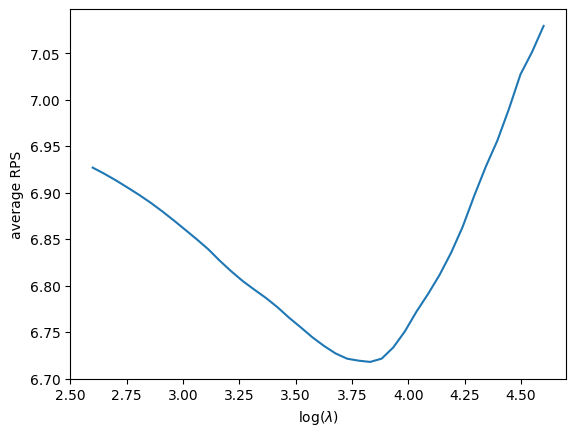

In [14]:
folds_number=7
subsets_indexes=np.linspace(0,x_train_augmente.shape[0],folds_number,dtype=int)
lambdas=np.logspace(2.6,4.6,40)
best_lambda,losses = record_loss_curve_cross_validation(x_train_augmente,y_train,lambdas,T_fold_cross_validation_time,subsets_indexes,'$\lambda$')
plt.plot(np.log10(lambdas),losses)
plt.xlabel(f'log($\lambda$)')
plt.ylabel("average RPS")
plt.show()




In [15]:
betas=minimize_ls_lasso(x_train_augmente,y_train,best_lambda)

Now we can see which are the best features selected by LASSO algorithm and plot a feature importance histogram

Top 15 Features (lambda = 6773)


,Feature,Beta_Value,Absolute_Importance,Relative_Importance
2,team_points_stats_last_10,2.371875,2.371875,1.000000
59,opp_opponent_points_last_10,2.184159,2.184159,0.920857
60,is_home,0.749287,0.749287,0.315905
41,opp_possessions_last_10,0.580261,0.580261,0.244642
57,opp_opponent_points_last_3,0.249093,0.249093,0.105019
1,team_points_stats_last_5,0.198215,0.198215,0.083569
0,team_points_stats_last_3,0.197515,0.197515,0.083274
47,opp_3FG_PCT_last_10,-0.101548,0.101548,0.042813
58,opp_opponent_points_last_5,0.090029,0.090029,0.037957
39,opp_possessions_last_3,0.053244,0.053244,0.022448


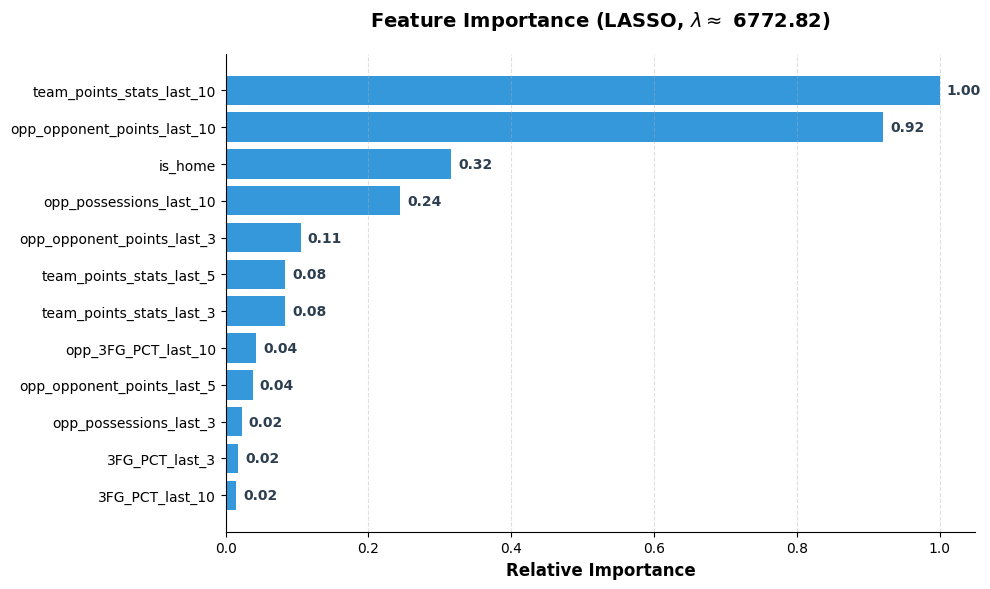

In [16]:

importance_df = pd.DataFrame({
    'Feature': statistics_names, 
    'Beta_Value': betas[1:], 
    'Absolute_Importance': np.abs(betas[1:]),
    'Relative_Importance' : np.abs(betas[1:])/np.max(abs(betas[1:]))
})


importance_df = importance_df.sort_values(by='Absolute_Importance', ascending=False)
print(f"Top 15 Features (lambda = {best_lambda:.0f})")
display(importance_df.head(15))

important_features = importance_df.head(12)['Feature']

treshold = 0.01 
df_plot = importance_df[importance_df['Relative_Importance'] > treshold].copy()

df_plot = df_plot.sort_values(by='Relative_Importance', ascending=True)

plt.figure(figsize=(10, max(6, len(df_plot) * 0.4))) 


bars = plt.barh(df_plot['Feature'], df_plot['Relative_Importance'], color='#3498db')


for bar in bars:
    largeur = bar.get_width()
    plt.text(largeur + 0.01, bar.get_y() + bar.get_height()/2, 
             f'{largeur:.2f}', 
             va='center', ha='left', fontsize=10, fontweight='bold', color='#2c3e50')

plt.xlabel('Relative Importance', fontsize=12, fontweight='bold')
plt.title(fr'Feature Importance (LASSO, $\lambda \approx$ {best_lambda:.2f})', fontsize=14, fontweight='bold', pad=20)
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

It is always interesting to plot the feature coefficients as a function of lambda, to see the shrinkage operated by LASSO.

<>:18: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:22: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:18: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:22: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
C:\Users\leand\AppData\Local\Temp\ipykernel_3404\1059696285.py:18: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  plt.xlabel('log($\lambda$)')
C:\Users\leand\AppData\Local\Temp\ipykernel_3404\1059696285.py:22: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will n

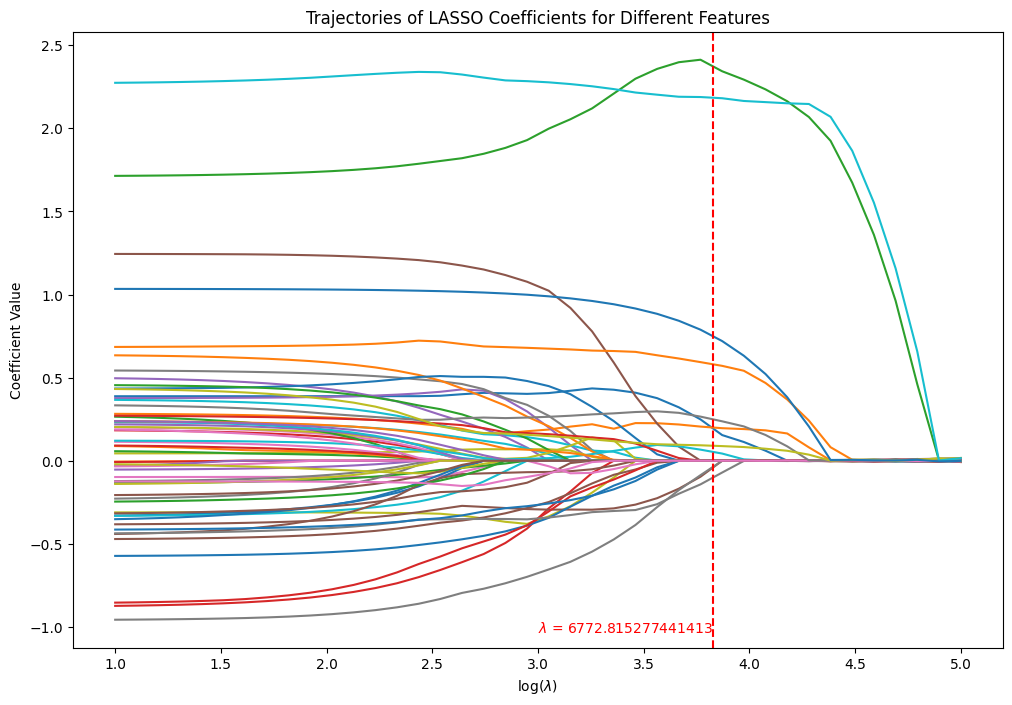

In [17]:
lambdas=np.logspace(1,5,40) 
coeff_trajectories = []
for lam in lambdas:
    # Run LASSO regression
    beta_lasso = minimize_ls_lasso(x_train_augmente, y_train, lambd=lam, n_iters=15000,
                                    step_size=1e-7,
                                    c_huber=1e-5)
    coeff_trajectories.append(beta_lasso[1:])

coeffs=np.vstack(coeff_trajectories)

# plot the trajectores of LASSO coefficients using log-scale
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 8))
for i in range(coeffs.shape[1]):
    plt.plot(np.log10(lambdas), coeffs[:, i], label=f'Feature {i + 1}')

plt.xlabel('log($\lambda$)')
plt.ylabel('Coefficient Value')
plt.title('Trajectories of LASSO Coefficients for Different Features')
plt.axvline(x=np.log10(best_lambda), color='red', linestyle='--')
plt.text(np.log10(best_lambda), 0.02, f' $\lambda$ = {best_lambda} ', 
         color='red', 
         transform=plt.gca().get_xaxis_transform(),
         ha='right', 
         va='bottom',
         fontsize=10)
plt.show()

To determine wether the model is efficient, we compare its RPS with naive approach considering team point distribution as normal with mean the mean of the 10 previous team points and standard deviation the MSE of residuals. 

We compare the score on the test set. 


In [18]:
naive_errors_train = df_final_without_na['team_points'].values[:index_max] - df_final_without_na['team_points_stats_last_10'].values[:index_max]
naive_sigma = np.std(naive_errors_train)
naive_means = df_final_without_na['team_points_stats_last_10'].values[index_max:]
naive_cdf = discretize_normal_cdf(naive_means, naive_sigma, support_max=200)
naive_rps = ranked_probability_score(naive_cdf, y_test, support=np.arange(201))


model_means = x_test_augmente@betas
past_model = x_train_augmente@betas
residuals = past_model-y_train
model_sigma = np.std(residuals)
model_cdf = discretize_normal_cdf(model_means,model_sigma, support_max=200)
model_rps = ranked_probability_score(model_cdf, y_test, support=np.arange(201))



print(f"RPS of naive model: {naive_rps:.4f}")
print(f"RPS of LASSO model: {model_rps:.4f}")
print(f"Skill Score :  {(1 -model_rps/naive_rps) *100:.4f}%")

RPS of naive model: 7.3309
RPS of LASSO model: 6.8463
Skill Score :  6.6099%


In [19]:
important_index = [statistics_names.index(feature) for feature in important_features]


# x_train_Tree = x_train_standardize
x_train_Tree = x_train_standardize[:,important_index] 
x_test_Tree = x_test_standardize[:,important_index] 

Here we build random forests. To do so, for more clarity, we use object-oriented programming aspect of python. We define the following classes : 
* Class Node, which are the structures of trees in forests. They are defined by treshold and dimension to decide how to split data. 
* Class Tree, which implement the methods to train decision trees. A tree is only a linked list of nodes, hence we can define them by the head of the list
* Class RandomForest, which implement the methods to train random forest i.e with both bootstrap aggregating and feature bagging. Random Forests are just list of such trained trees trained on random samples and selected features (at each split)

In [20]:

class Node: 
    def __init__(self, dimension_number=None, treshold=None):
        self.dimension_number = dimension_number
        self.treshold = treshold
        self.left = None
        self.right = None
        self.probability_distribution = None 

    def add_left(self, child_node):
        self.left = child_node

    def add_right(self, child_node):    
        self.right = child_node 

    def get_left_son(self):
        return self.left
        
    def get_right_son(self):
        return self.right


In [29]:
class Tree: 

    def __init__(self,max_depth,min_std,max_features): 
        self.head = None
        self.max_depth=max_depth
        self.min_std = min_std
        self.max_features=max_features #for feature bagging 


    def training(self,x_train,y_train): 
        features = np.arange(x_train.shape[1])
        self.head= self.build_Nodes(x_train,y_train,features)
    

    def build_Nodes(self,x_train,y_train,features,depth=0) :

        if np.std(y_train) < self.min_std or y_train.shape[0] < 2 or depth > self.max_depth:
            leaf = Node()
            leaf.probability_distribution = self.point_distribution(y_train)
            return leaf 
        
        random_features=np.random.choice(features,self.max_features,replace=False)
        column, treshold = self.best_split(x_train,y_train,random_features)
        
        if column is None:
            leaf = Node()
            leaf.probability_distribution = self.point_distribution(y_train)
            return leaf 
            
        x_left, x_right, y_left, y_right = self.split(x_train, y_train, column, treshold)
        

        left_child = self.build_Nodes(x_left,y_left,features,depth+1) 
        right_child = self.build_Nodes(x_right,y_right,features,depth+1) 
        
        parent = Node(column,treshold)
        parent.add_left(left_child) 
        parent.add_right(right_child)

        return parent


    def get_distributions(self,x,support):
        sample_size= x.shape[0]
        distributions = np.zeros((sample_size, len(support))) #initializing distribution
        for k in range(sample_size) :
            data_point = x[k]
            current_Node = self.head

            while current_Node.probability_distribution is None:  
                column = current_Node.dimension_number
                treshold = current_Node.treshold
                if data_point[column] < treshold: 
                    current_Node = current_Node.get_left_son()
                else:
                    current_Node = current_Node.get_right_son()

            probability_distribution = current_Node.probability_distribution
            for point,proba in probability_distribution.items():
                index = np.where(point == support) #for general supports. 
                if len(index) > 0:
                    distributions[k, index] = proba
        return distributions
    

    
    def split(self,x, y, column, treshold):
        mask_index = x[:, column] < treshold
        x_left = x[mask_index]
        x_right = x[~mask_index]
        y_left = y[mask_index]
        y_right = y[~mask_index]
        return x_left, x_right, y_left, y_right
    


    def best_split(self, x_train, y_train, random_features):
        n = y_train.shape[0]
        mini_cost = np.inf
        current_best_split = (None, None)

        total_sum = np.sum(y_train)
        total_sum2 = np.sum(y_train**2)

        for column in random_features:
            order = np.argsort(x_train[:, column])
            x_sorted = x_train[order, column]
            y_sorted = y_train[order]

            
            cum_y = np.cumsum(y_sorted)
            cum_y2 = np.cumsum(y_sorted**2)

            #candidates treshold
            boundaries = np.where(np.diff(x_sorted) != 0)[0] + 1
            if boundaries.size == 0:
                continue  

            k = boundaries                      
            n_left = k
            n_right = n - k

            sum_left = cum_y[k - 1]
            sum2_left = cum_y2[k - 1]
            sum_right = total_sum - sum_left
            sum2_right = total_sum2 - sum2_left

            mean_left = sum_left / n_left
            var_left = np.maximum(sum2_left / n_left - mean_left**2, 0)
            std_left = np.sqrt(var_left)

            mean_right = sum_right / n_right
            var_right = np.maximum(sum2_right / n_right - mean_right**2, 0)
            std_right = np.sqrt(var_right)

            cost = (n_left / n) * std_left + (n_right / n) * std_right

            best_idx = np.argmin(cost)
            if cost[best_idx] < mini_cost:
                mini_cost = cost[best_idx]
                current_best_split = (column, x_sorted[k[best_idx]])

        return current_best_split

    def point_distribution(self,y):
        n = y.shape[0]
        probability_distribution = {}
        for point in np.unique(y):
            count = np.sum(y == point)
            probability_distribution[point] = count / n 

        return probability_distribution


In [41]:
from joblib import Parallel, delayed
def train_single_tree(max_depth, min_std, m, x_train, y_train):
    n_samples = y_train.shape[0]
    model = Tree(max_depth, min_std, m)
    random_index = np.random.choice(n_samples, size=n_samples, replace=True) #1/3 out of bag with size=n_samples. If n is big we can indeed use the equivalence of 1/e.
    model.training(x_train[random_index, :], y_train[random_index])
    print('trained')
    return model


class RandomForest :
    def __init__(self,B,m,max_depth,min_std,n_jobs=-1):
        self.trees = []
        self.B=B
        self.m=m
        self.max_depth=max_depth
        self.min_std=min_std
        self.n_jobs=n_jobs
        
    def train_forest(self,x_train,y_train):
        self.trees = Parallel(n_jobs=self.n_jobs)(
            delayed(train_single_tree)(
                self.max_depth, self.min_std, self.m, x_train, y_train
            ) 
            for _ in range(self.B)
        )

    def get_distribution(self,x,support):
        trees_predictions= []
        for model in self.trees: 
            distributions = model.get_distributions(x,support)
            trees_predictions.append(distributions)

        predictions = np.mean(trees_predictions,axis=0)
        
        return predictions
    

In [ ]:
def T_fold_cross_validation_forest(x_train,y_train,subsets_indexes,min_std) : 
    errors=[]
    for k in range(1,len(subsets_indexes)-1): 
        subset_index=subsets_indexes[k]
        next_subset_index=subsets_indexes[k+1]
        x_train_t=x_train[:subset_index,:]
        y_train_t=y_train[:subset_index]
        x_val=x_train_Tree[subset_index:next_subset_index,:]
        y_val=y_train[subset_index:next_subset_index]
        B=15
        depth = 8
        forest=RandomForest(B,x_train.shape[1]-1,depth,min_std)
        forest.train_forest(x_train_t,y_train_t)
        support=np.arange(200)
        predicted_distribution = forest.get_distribution(x_val,support)
        error= ranked_probability_score(predicted_distribution, y_val, support)
        errors.append(error)
    
    return np.mean(errors)



<>:7: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:7: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
C:\Users\leand\AppData\Local\Temp\ipykernel_3404\1520268360.py:7: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  plt.xlabel(f"$\sigma$")


10.0
Test for $lambda$ = 10.0000, average RPS = 6.7527 , iteration number: 1/15
10.285714285714286
Test for $lambda$ = 10.2857, average RPS = 6.7281 , iteration number: 2/15
10.571428571428571
Test for $lambda$ = 10.5714, average RPS = 6.7177 , iteration number: 3/15
10.857142857142858
Test for $lambda$ = 10.8571, average RPS = 6.7328 , iteration number: 4/15
11.142857142857142
Test for $lambda$ = 11.1429, average RPS = 6.7152 , iteration number: 5/15
11.428571428571429
Test for $lambda$ = 11.4286, average RPS = 6.7100 , iteration number: 6/15
11.714285714285714
Test for $lambda$ = 11.7143, average RPS = 6.7242 , iteration number: 7/15
12.0
Test for $lambda$ = 12.0000, average RPS = 6.7750 , iteration number: 8/15
12.285714285714285
Test for $lambda$ = 12.2857, average RPS = 6.8436 , iteration number: 9/15
12.571428571428571
Test for $lambda$ = 12.5714, average RPS = 7.0473 , iteration number: 10/15
12.857142857142858
Test for $lambda$ = 12.8571, average RPS = 7.1842 , iteration number

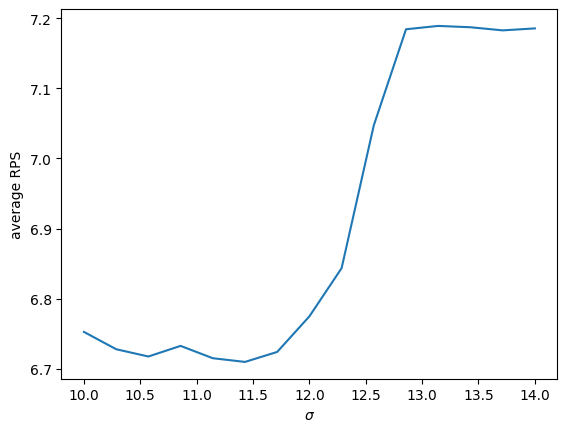

In [ ]:
folds_number=5
subsets_indexes=np.linspace(0,x_train_Tree.shape[0],folds_number,dtype=int)
sigmas = np.linspace(10, 14.0,15)

best_lambda,losses = record_loss_curve_cross_validation(x_train_Tree,y_train,sigmas,T_fold_cross_validation_forest,subsets_indexes,'sigma')
plt.plot(sigmas,losses)
plt.xlabel(f"$\sigma$")
plt.ylabel("average RPS")
plt.show()



In [ ]:
forest=RandomForest(200,x_train_Tree.shape[1]-1,8,11.428571) 
forest.train_forest(x_train_Tree,y_train)
support=np.arange(200) #team points range
predicted_distribution = forest.get_distribution(x_test_Tree,support)
forest_rps = ranked_probability_score(predicted_distribution,y_test, support)


print(f"RPS of naive model: {naive_rps:.4f}")
print(f"RPS of LASSO model: {model_rps:.4f}")
print(f"RPS of forest model: {forest_rps:.4f}")
print(f"Skill Score :  {(1 -forest_rps/naive_rps) *100:.4f}%")

RPS of naive model: 7.3309
RPS of LASSO model: 6.8463
RPS of forest model: 6.8760
Skill Score :  6.2057%
